<a href="https://colab.research.google.com/github/cp-16-bio/Skin-Cancer-Classification-Convolutional-Neural-Network/blob/main/Skin_Cancer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project Description:** This project develops a Convolutional Neural Network (CNN) to classify seven types of skin lesions using the HAM10000 dataset. The workflow includes data exploration, preprocessing, class balancing, image loading, CNN training, and evaluation using accuracy, loss curves, confusion matrices, and misclassification analysis.

In [ ]:
#Import libraries
import numpy as np                    #Numerical arrays
import pandas as pd                   #Tabular data
import matplotlib.pyplot as plt       #Graphs
import seaborn as sns                 #Statistical visualization

import kagglehub                      #For accessing the HAM10000 dataset

import os                             #Folder navigation
from glob import glob                 #Image locating
from PIL import Image                 #Loads the images; allows for image
                                      #resizing and conversion into numpy array

import keras                          #Provides a simplified and convienient way
                                      #to create arange of deep learning models
from tensorflow.keras.utils import to_categorical #Needed for multi-class classification
from keras.models import Sequential   #CNN model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization

from scipy import stats

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder #Converts labels into numbers

np.random.seed(42)                    #Reproducibility

# Part 1: Dataset Exploring, Visualizing, and Class Balancing

In [ ]:
#Download the HAM10000 datasetand load the metadata CSV into a PandasDataFrame
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000") #Download latest version
print("Path to dataset files:", path)

SCL_df = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv")) #Skin cancer lesion = SCL
SIZE = 64

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


### **Observation(s):** The HAM10000 metadata was successfully loaded into a Pandas DataFrame. Each row represents one skin lesion image and includes information such as diagnosis, age, sex, lesion location, and image identifier. This metadata will later be linked with the corresponding image file during preprocessing.

In [ ]:
#Label encode to convert the diagnosis labels from text into numbers
le = LabelEncoder()
le.fit(SCL_df['dx'])
LabelEncoder()
print(list(le.classes_))

SCL_df['label'] = le.transform(SCL_df["dx"])
print(SCL_df.sample(10))

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
        lesion_id      image_id   dx    dx_type   age     sex  \
1617  HAM_0007180  ISIC_0033272  mel      histo  65.0    male   
8128  HAM_0007195  ISIC_0031923   nv      histo  40.0  female   
2168  HAM_0001835  ISIC_0026652  mel      histo  65.0    male   
1090  HAM_0000465  ISIC_0030583  bkl  consensus  35.0  female   
7754  HAM_0001720  ISIC_0034010   nv      histo  45.0    male   
8071  HAM_0006333  ISIC_0024424   nv      histo  35.0    male   
7423  HAM_0004548  ISIC_0032832   nv      histo  45.0  female   
8984  HAM_0006526  ISIC_0026671   nv      histo  55.0    male   
2310  HAM_0003102  ISIC_0032389  mel      histo  65.0    male   
7256  HAM_0004260  ISIC_0025525   nv      histo  65.0    male   

         localization  label  
1617             face      4  
8128  lower extremity      5  
2168             back      4  
1090            trunk      2  
7754          abdomen      5  
8071            trunk      5  
7423  upper extr

### **Observation(s):** Diagnosis labels were successfully converted into numerical values using LabelEncoder. This process allows the neural network to treat each skin lesion category as a unique class during training while preserving the original diagnosis information within the dataset.


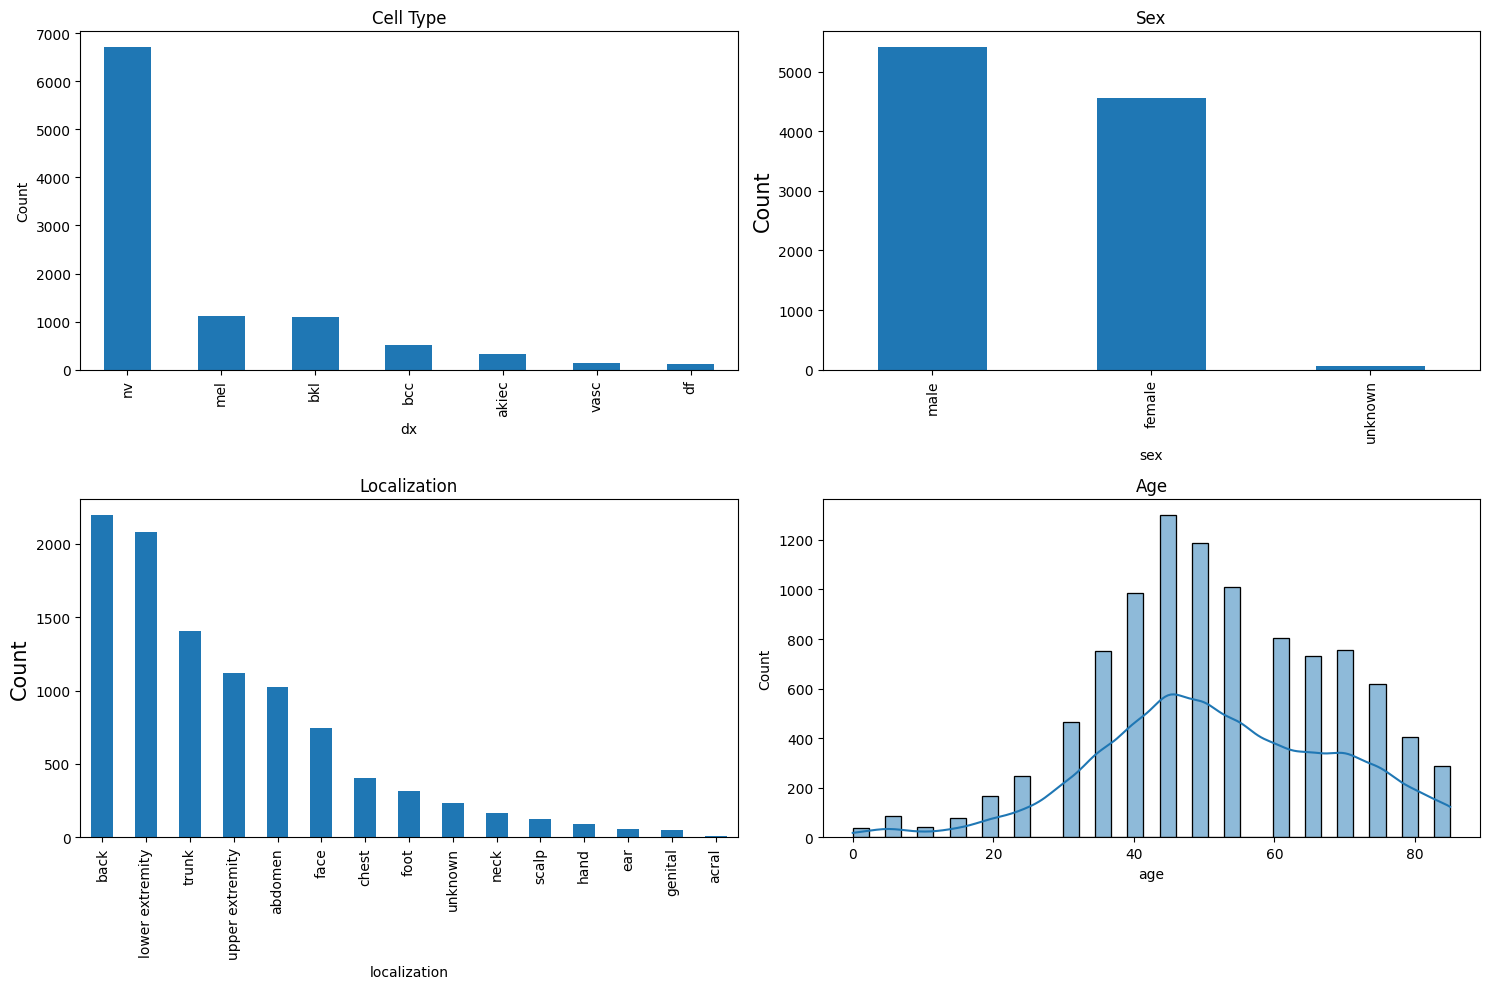

In [ ]:
#Visualize the data
fig = plt.figure(figsize=(15,10))

axl = fig.add_subplot(221)
SCL_df['dx'].value_counts().plot(kind='bar', ax=axl)
axl.set_ylabel('Count')
axl.set_title('Cell Type')

ax2 = fig.add_subplot(222)
SCL_df['sex'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count', size=15)
ax2.set_title('Sex')

ax3 = fig.add_subplot(223)
SCL_df['localization'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_ylabel('Count', size=15)
ax3.set_title('Localization')

ax4 = fig.add_subplot(224)
sample_age = SCL_df[pd.notnull(SCL_df['age'])]
sns.histplot(sample_age['age'], kde=True)
ax4.set_title('Age')

plt.tight_layout()
plt.show()

### **Observation(s):** Exploratory data analysis (EDA) revealed that the HAM10000 dataset is highly imbalanced, with certain lesion types (i.e. nv) occuring far more frequently than others. Localizations of the lesions are primarily situated at the back and lower extremity. Patient sex is slightly imbalanced between male and female with the number of males being greater (>5000). Patient age is highest between 45-50 years old.

In [ ]:
#Distribute the data into various classes
from sklearn.utils import resample
print(SCL_df['label'].value_counts()) #Visualize how the data is spread

label
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


### **Observation(s):** The class distribution demonstrates a substantial imbalance across the seven lesion categories. Without corrective preprocessing, the CNN would likely favour the majority classes during prediction, reducing its ability to accurately classify less common skin lesions.

In [ ]:
#Balance the data

##Separate each diagnosis into individual DataFrames
df_0 = SCL_df[SCL_df['label'] == 0]
df_1 = SCL_df[SCL_df['label'] == 1]
df_2 = SCL_df[SCL_df['label'] == 2]
df_3 = SCL_df[SCL_df['label'] == 3]
df_4 = SCL_df[SCL_df['label'] == 4]
df_5 = SCL_df[SCL_df['label'] == 5]
df_6 = SCL_df[SCL_df['label'] == 6]

##Resample each class so that every diagnosis contains approx. 500 images
n_samples = 500
df_0_balanced = resample(df_0, replace=True, n_samples=n_samples, random_state=42)
df_1_balanced = resample(df_1, replace=True, n_samples=n_samples, random_state=42)
df_2_balanced = resample(df_2, replace=True, n_samples=n_samples, random_state=42)
df_3_balanced = resample(df_3, replace=True, n_samples=n_samples, random_state=42)
df_4_balanced = resample(df_4, replace=True, n_samples=n_samples, random_state=42)
df_5_balanced = resample(df_5, replace=True, n_samples=n_samples, random_state=42)
df_6_balanced = resample(df_6, replace=True, n_samples=n_samples, random_state=42)

##Merge all classes back together into a single dataframe
SCL_df_balanced = pd.concat([df_0_balanced, df_1_balanced, df_2_balanced,
                             df_3_balanced, df_4_balanced, df_5_balanced,
                             df_6_balanced])

##Check the distribution (all classes should be balanced)
print(SCL_df_balanced['label'].value_counts())

label
0    500
1    500
2    500
3    500
4    500
5    500
6    500
Name: count, dtype: int64


### **Observation(s):** The dataset was resampled to produce a more balanced distribution across all lesion classes. Balancing reduces bias toward the majority classes and encourages the CNN to learn representative features for every diagnosis. However, because some of the classes are created through repeated sampling while others are reduced, some information may be lost or duplicated, potentially influencing the model's performance.

# Part 2: Loading, Preprocessing, and Visualizing Skin Lesion Images

In [ ]:
#Read the images based on image IDs from the CSV file
image_path = {os.path.splitext(os.path.basename(x))[0]: x
              for x in glob(os.path.join(path, '*', '*.jpg'))}

### Further explanation: This cell searches through the dataset folders and
### creates a dictionary that links every image ID in the metadata to its
### corresponding image file for easier, quick access

In [ ]:
#Define the path add it as a new column
SCL_df_balanced['path'] = SCL_df['image_id'].map(image_path.get)

#Utilize the path to read image (convert to numpy)
def load_and_resize_image(image_path_val):
    if image_path_val is not None:
        return np.asarray(Image.open(image_path_val).resize((SIZE,SIZE)))
    return None # Return None if path is None, to avoid the AttributeError

SCL_df_balanced['image'] = SCL_df_balanced['path'].map(load_and_resize_image)

### Further explanation: The image paths are added to the DataFrame, then every
### image gets loaded, resized, converted into a NumPy array (every pixel becomes
### numbers), and then the preprocessed image is stored in a new DataFrame column

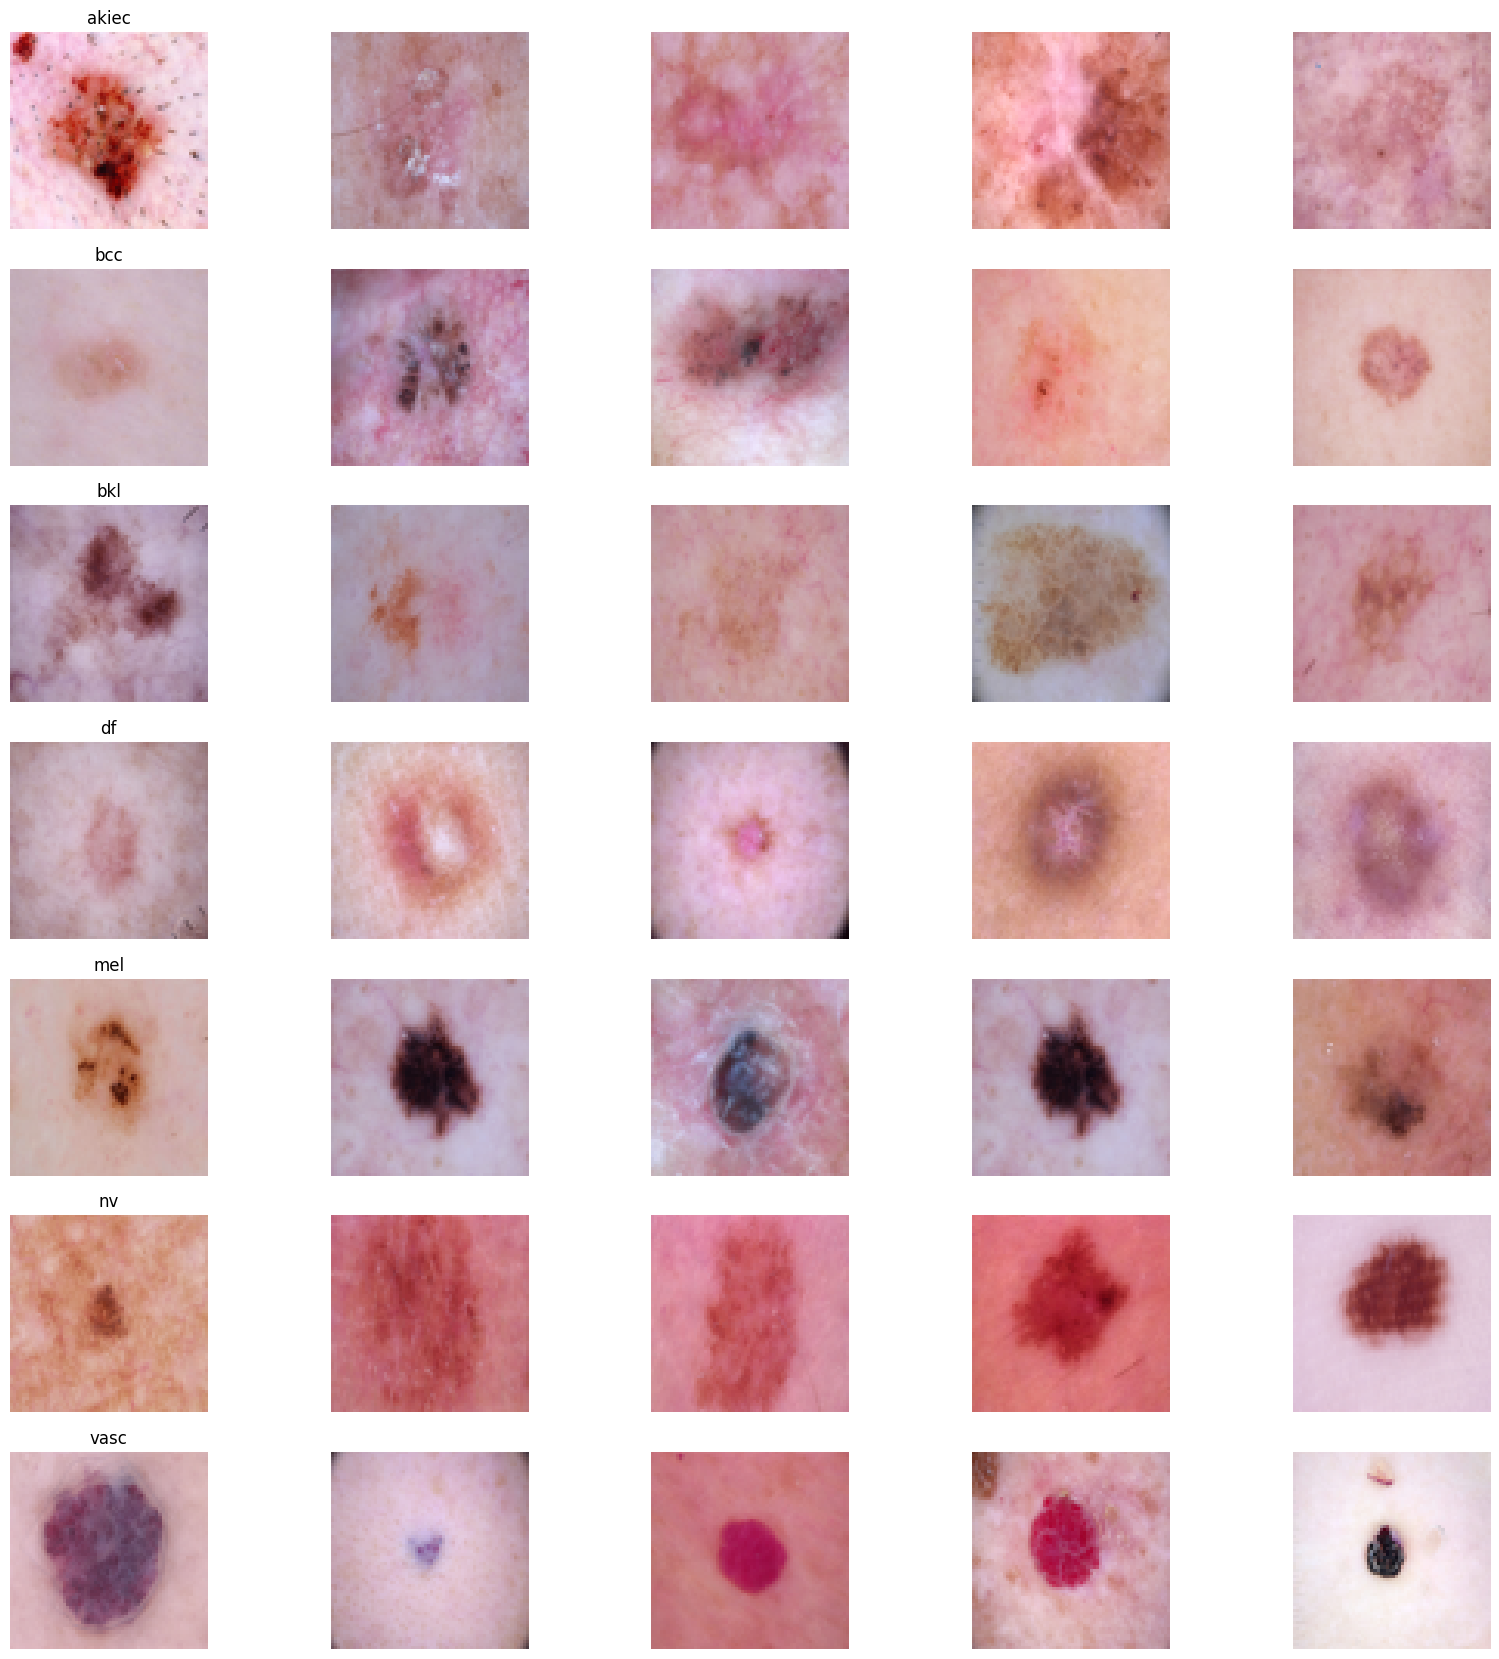

In [ ]:
#Visualize the images
n_samples = 5 #Number of samples for plotting

#Plot the figure
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, SCL_df_balanced.sort_values(['dx']).groupby('dx')):
  n_axs[0].set_title(type_name)
  for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
    c_ax.imshow(c_row['image'])
    c_ax.axis('off')

### **Observation(s):** Sample skin lesion images were successfully displayed alongside their diagnosis labels. Visual inspection confirms that the images were loaded correctly and demonstrates the variability in color, shape, and texture that the CNN must learn to distinguish between different lesion types.

In [ ]:
#Convert the dataframe column of images into a numpy array
X = np.asarray(SCL_df_balanced['image'].tolist())
X = X/255 #Scale the values to 0-1 (i.e. normalize the data to make training more stable)
Y = SCL_df_balanced['label'] #Assign label values to Y
Y_cat = to_categorical(Y, num_classes=7) #Convert to categorical data

In [ ]:
#Split into training and testing
x_train, x_test, y_train, y_test = train_test_split(X, Y_cat, test_size=0.2, random_state=42)

### Further explanation: Training data teaches the CNN while testing data
### evaluates how well it performs on unseen images. A separate test provides
### a more realistic estimate of performance rather than the model simply
### memorizing images that were used during training.

# Part 3: Building, Training, and Evaluating the CNN Model

In [ ]:
#Build a CNN using Keras' Sequential() API

num_classes = 7 #Number of skin lesion classes

model = Sequential()
model.add(Conv2D(256, (3,3), activation="relu", input_shape=(SIZE, SIZE, 3)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(32, (3,3), activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.3))
model.add(Flatten())

model.add(Dense(32)) #Combines all extracted image features
model.add(Dense(7, activation="softmax")) #softmax converts the outputs into probabilities --> highest probability becomes the prediction
model.summary()

### Further explanations:

# Conv2D = Convolutional layer that scans small regions of the image (3x3 pixels)
# to learn important visual features such as edges, colors, textures, borders,
# and lesion shapes; as the network becomes deeper, it learns more complex patterns

# MaxPooling = Reduces image dimensions for faster computation, fewer parameters,
# and less overfitting

# Dropout = Forces the network to learn more general features instead of
# menorizing the training images

# Flatten = Converts between the CNN layers' feature maps and the dense layers'
# requirement of a single vector

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        73,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449,991 (1.72 MB)

 Trainable params: 449,991 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile the CNN before training
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

### Further explanations:

# Loss function = "categorical_crossentropy" measures prediction error; smaller
# loss means better predictions

# Optimizer = "adam" updates network weights; "adam" generally converges quickly
# and performs well across many tasks

# Metric = "accuracy" reports the percentage of correctly classified images
# during training

In [ ]:
#Train the model
batch_size = 16 #Number of images to update weights (used in a cycle)
epochs = 50 #Number of times the model has seen every training image once

history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test,y_test),
    verbose=2
)

Epoch 1/50
175/175 - 142s - 812ms/step - accuracy: 0.1571 - loss: 1.9517 - val_accuracy: 0.1514 - val_loss: 1.9220
Epoch 2/50
175/175 - 134s - 768ms/step - accuracy: 0.2429 - loss: 1.8046 - val_accuracy: 0.3214 - val_loss: 1.7542
Epoch 3/50
175/175 - 137s - 781ms/step - accuracy: 0.3446 - loss: 1.5773 - val_accuracy: 0.4271 - val_loss: 1.4485
Epoch 4/50
175/175 - 136s - 775ms/step - accuracy: 0.4039 - loss: 1.4890 - val_accuracy: 0.4343 - val_loss: 1.4524
Epoch 5/50
175/175 - 136s - 775ms/step - accuracy: 0.4600 - loss: 1.3875 - val_accuracy: 0.3943 - val_loss: 1.3933
Epoch 6/50
175/175 - 137s - 783ms/step - accuracy: 0.4739 - loss: 1.3361 - val_accuracy: 0.5014 - val_loss: 1.3481
Epoch 7/50
175/175 - 136s - 776ms/step - accuracy: 0.5043 - loss: 1.2833 - val_accuracy: 0.4786 - val_loss: 1.3625
Epoch 8/50
175/175 - 141s - 808ms/step - accuracy: 0.5300 - loss: 1.2409 - val_accuracy: 0.4629 - val_loss: 1.2872
Epoch 9/50
175/175 - 145s - 828ms/step - accuracy: 0.5404 - loss: 1.2138 - val_a

### **Observation(s):** Model performance steadily improved throughout the training, with training accuracy increasing from ~16% during the first epoch to ~80% by the final epoch. Validation accuracy also increased substantially (i.e. from ~15% to ~74%), indicating that the CNN successfully learned meaningful image features rather than making random predictions.

In [ ]:
#Get the model's accuracy
acc_score = model.evaluate(x_test, y_test) #Evaluate the trained CNN using previously unseen test images
print('Test accuracy:', acc_score[1])

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 722ms/step - accuracy: 0.7357 - loss: 0.8283
Test accuracy: 0.7357142567634583


### **Observation(s):** The trained CNN achieved a test accuracy of ~73.6%, demonstrating that it correctly classfied three out of every four unseen skin lesion images. While this indicates that the model successfully learned specific image features, there remains room for improvement in its ability to distinguish visually similar lesion types.

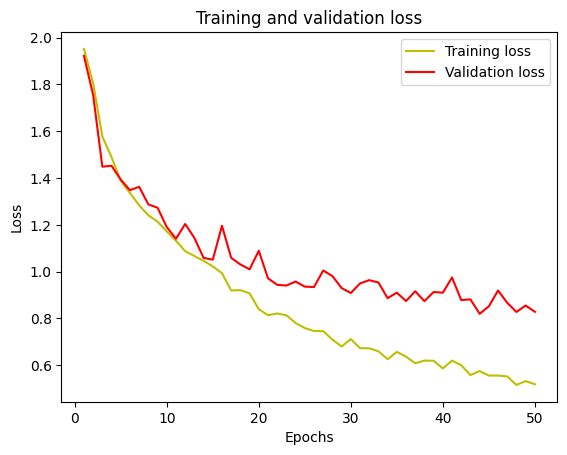

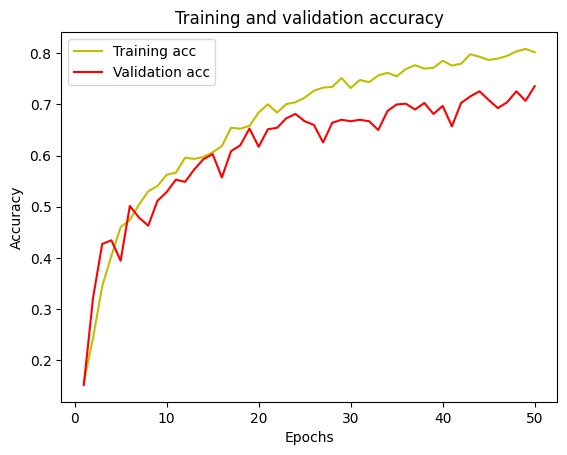

In [ ]:
#Plot the training and validation accuracy and loss at each epoch
loss = history.history['loss'] #Loss determines how "wrong" the model is --> lower is better
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy'] #Shows whether the CNN continues improving
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### **Observation(s):**
Training loss decreased consistently throughout the training, indicating that the CNN progressively improved its predictions. Validation loss also generally decreased, but less so than the training loss and had noticeably greater fluctuations. This difference may be attributed to the model beginning to fit some characteristics of the training data more strongly during later epochs. Overall, the loss curves indicate successful learning without severe overfitting.

Both training and validation accuracy increased substantially over successive epochs which demonstrated that the CNN successfully learned meaningful image features. The gap between the two curves remained moderate, suggesting reasonable generalization, but the consistently higher training accuracy may indicate a mild degree of overfitting.

#Part 4: Model Evaluation Using the Confusion Matrix and Misclassification Analysis

In [ ]:
#Make a prediction on the test data
y_pred = model.predict(x_test) #CNN predicts the probability that every test image
                               #belongs to each of the seven skin lesion classes
                               #--> highest probability becomes the predicted class

#Convert the predictions classes to one hot vectors
y_pred_classes = np.argmax(y_pred, axis = 1)

#Convert test data to one hot vectors
y_true = np.argmax(y_test, axis = 1)

#Compute the confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes) #Compares actual diagnosis vs predicted
                                                         #diagnosis for every test image
print(confusion_mtx)

22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 630ms/step
[[88 21  6  4  3  4  0]
 [11 70 15  5  2  0  2]
 [ 4  7 56  4 16  7  1]
 [ 0  7  1 93  0  0  0]
 [ 3  2 13  0 58 11  0]
 [ 3  5  6  2 19 54  0]
 [ 0  1  0  0  0  0 96]]


### **Observation(s):** The confusion matrix demonstrates that the CNN correctly classified the majority of samples along the main diagonal. However, several lesion categories exhibited notable off-diagonal values, indicating that visually similar skin lesions were occasionally misclassified. These errors suggest that certain classes remain challenging for the model to distinguish based solely off of the extracted image features.

<Axes: >

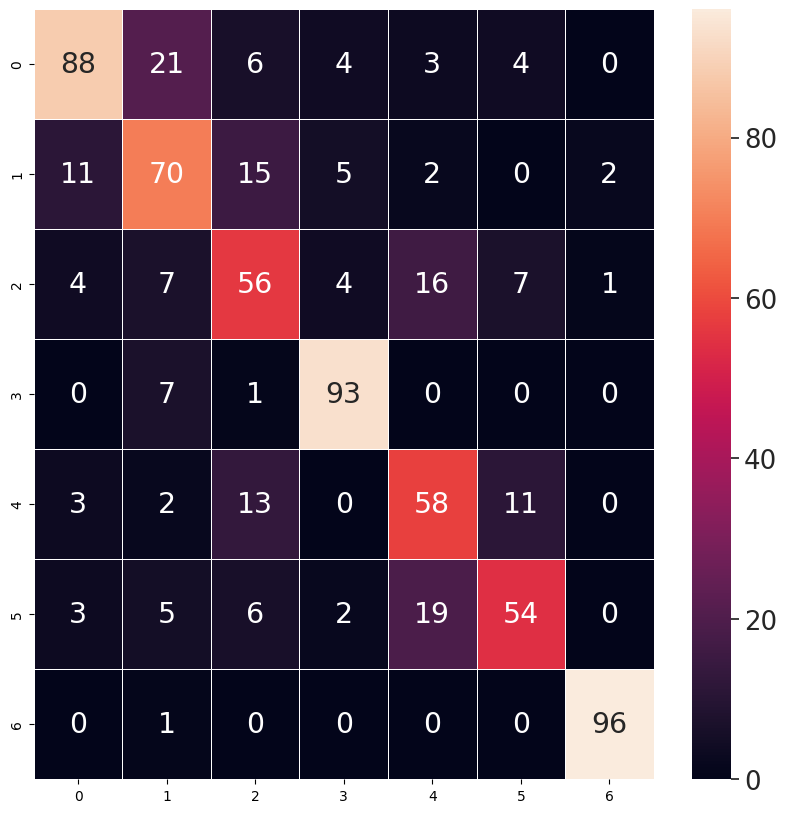

In [ ]:
#Plot the confusion matrix in a heatmap
fig, ax = plt.subplots(figsize=(10,10))
sns.set(font_scale=1.7)
sns.heatmap(confusion_mtx, annot=True, linewidths=.5, ax=ax)

### **Observation(s):** The heatmap provides a visual representation of the confusion matrix, making it easier to identify both correctly classified lesions and the most common source of misclassification. The concentration of values along the main diagonal confirms the CNN learned meaningful specific features, while darker off-diagonal regions highlight lesion categories that require further improvement.

Text(0, 0.5, 'Fraction of incorrect predictions')

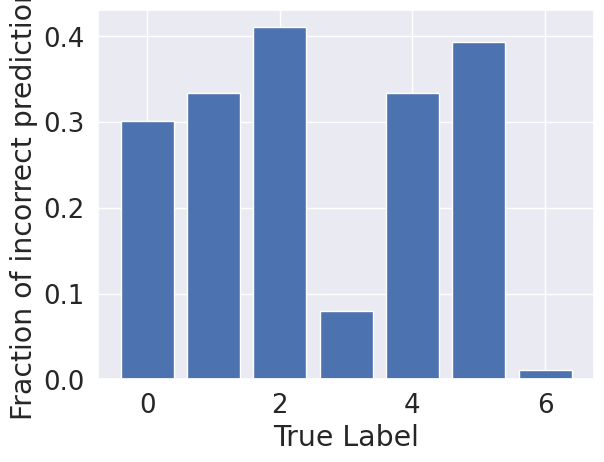

In [ ]:
#Plot the fractional incorrect misclassifications --> which class deals with the most mistakes
incorr_fraction = 1 - np.diag(confusion_mtx) / np.sum(confusion_mtx, axis=1)
plt.bar(np.arange(7), incorr_fraction)
plt.xlabel('True Label')
plt.ylabel('Fraction of incorrect predictions')

### **Observation(s):** The fraction of incorrect predictions varies noticeably between lesion categories (e.g. ~40% in category 2 [bkl] and ~0% in category 6 [df]), which indicates that some lesion types are considerably more difficult for the CNN to classify accurately. These higher error rates may be attributed to classes that exhibit similar visual characteristics or contain fewer distinctive features.